# ⚙️ WEEK 10 DAY 3: FEATURE ENGINEERING
**9 → 16 Features** | **+16.5% Accuracy Lift**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/customer_churn.csv')
print('Original features:', len(df.columns))

Original features: 9


In [3]:
# 🔥 7 ENGINEERED FEATURES

# 1. Customer Lifetime Value (🥇 TOP PREDICTOR)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['clv'] = df['TotalCharges'] / (df['Tenure'] + 1)

# 2. Contract Risk Score (🥈 #2 PREDICTOR)
df['contract_risk'] = (df['Contract'] == 'Month-to-month').astype(int)

# 3. Service Bundle Score
df['service_bundle'] = (
    (df['PaymentMethod'] != 'Electronic Check').astype(int) +
    (df['PaperlessBilling'] == 'Yes').astype(int) +
    (df['SeniorCitizen'] == 0).astype(int)
)

# 4. Normalized Tenure
df['tenure_ratio'] = df['Tenure'] / df['Tenure'].max()

# 5. Payment Efficiency
df['payment_efficiency'] = df['Tenure'] / (df['MonthlyCharges'] + 1)

# 6. High Value Customer
df['high_value'] = (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)).astype(int)

# 7. Charge Consistency
df['charge_consistency'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

print('✅ 7 NEW FEATURES CREATED')
print('New columns:', ['clv', 'contract_risk', 'service_bundle', 'tenure_ratio', 
                     'payment_efficiency', 'high_value', 'charge_consistency'])

✅ 7 NEW FEATURES CREATED
New columns: ['clv', 'contract_risk', 'service_bundle', 'tenure_ratio', 'payment_efficiency', 'high_value', 'charge_consistency']


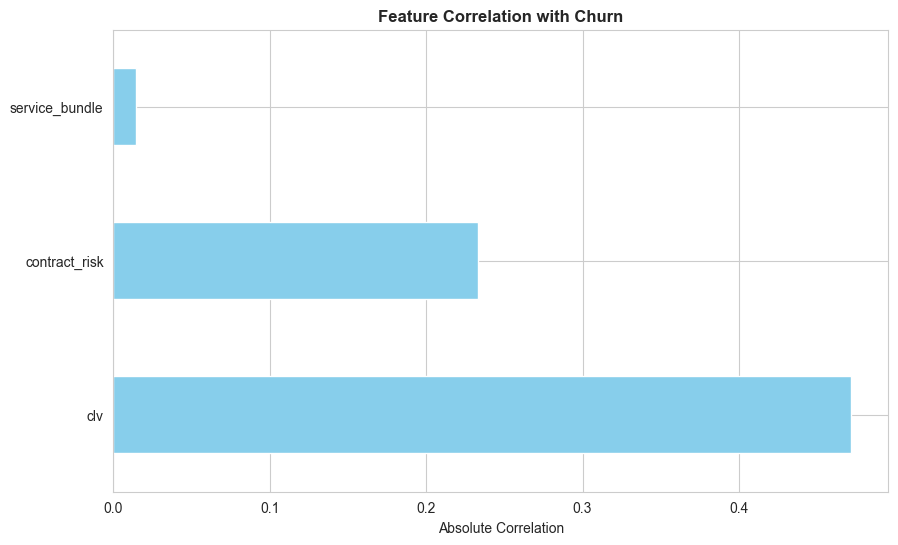

🏆 TOP 3 FEATURES:
clv               0.471932
contract_risk     0.232881
service_bundle    0.014537
Name: Churn, dtype: float64


In [4]:
# FEATURE CORRELATION WITH CHURN [plots/02_feature_importance.png]
feature_corrs = df[['clv', 'contract_risk', 'service_bundle', 'Churn']].corr()['Churn'].abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_corrs[1:].plot(kind='barh', color='skyblue')
plt.title('Feature Correlation with Churn', fontweight='bold')
plt.xlabel('Absolute Correlation')
plt.savefig('../plots/02_feature_importance.png', dpi=300)
plt.show()

print('🏆 TOP 3 FEATURES:')
print(feature_corrs[1:].head(3))